In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os.path as path
import seaborn as sns
from sklearn.preprocessing import StandardScaler

## 1.EDA Dataset Heart Attcak

In [20]:
df = pd.read_csv('../0.dataset/Heart_attack_dataset.csv')
df.head()

,patient_id,gender,age,body_mass_index,smoker,systolic_blood_pressure,hypertension_treated,family_history_of_cardiovascular_disease,atrial_fibrillation,chronic_kidney_disease,rheumatoid_arthritis,diabetes,chronic_obstructive_pulmonary_disorder,forced_expiratory_volume_1,time_to_event_or_censoring,heart_attack
0,PT00030699,F,31,25.9,0,112.0,1,0,0,0,0,0,0,90.969833,10,0
1,PT00018951,F,72,28.6,0,125.0,1,0,0,1,0,0,0,NaN,10,0
2,PT00027657,F,28,NaN,0,102.0,0,0,0,0,0,0,0,98.376954,10,0
3,PT00099298,F,63,NaN,0,NaN,0,0,0,0,0,0,0,NaN,10,0
4,PT00050564,F,35,NaN,0,111.0,1,0,0,0,0,0,0,NaN,10,0


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79583 entries, 0 to 79582
Data columns (total 16 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   patient_id                                79583 non-null  object 
 1   gender                                    79583 non-null  object 
 2   age                                       79583 non-null  int64  
 3   body_mass_index                           55751 non-null  float64
 4   smoker                                    79583 non-null  int64  
 5   systolic_blood_pressure                   71768 non-null  float64
 6   hypertension_treated                      79583 non-null  int64  
 7   family_history_of_cardiovascular_disease  79583 non-null  int64  
 8   atrial_fibrillation                       79583 non-null  int64  
 9   chronic_kidney_disease                    79583 non-null  int64  
 10  rheumatoid_arthritis              

In [22]:
df.shape

(79583, 16)

In [23]:
df.isnull().sum()

patient_id                                      0
gender                                          0
age                                             0
body_mass_index                             23832
smoker                                          0
systolic_blood_pressure                      7815
hypertension_treated                            0
family_history_of_cardiovascular_disease        0
atrial_fibrillation                             0
chronic_kidney_disease                          0
rheumatoid_arthritis                            0
diabetes                                        0
chronic_obstructive_pulmonary_disorder          0
forced_expiratory_volume_1                  55253
time_to_event_or_censoring                      0
heart_attack                                    0
dtype: int64

In [24]:
df.duplicated().sum()

np.int64(0)

In [25]:
feature_numerik = ['age','body_mass_index','systolic_blood_pressure','forced_expiratory_volume_1','time_to_event_or_censoring']
feature_categori = ['gender','smoker','hypertension_treated','family_history_of_cardiovascular_disease','atrial_fibrillation',
                    'chronic_kidney_disease','rheumatoid_arthritis','diabetes','chronic_obstructive_pulmonary_disorder','heart_attack']
feature_target = 'heart_attack'

In [26]:
df = df.drop(columns='patient_id', errors='ignore')
print(df.shape)

(79583, 15)


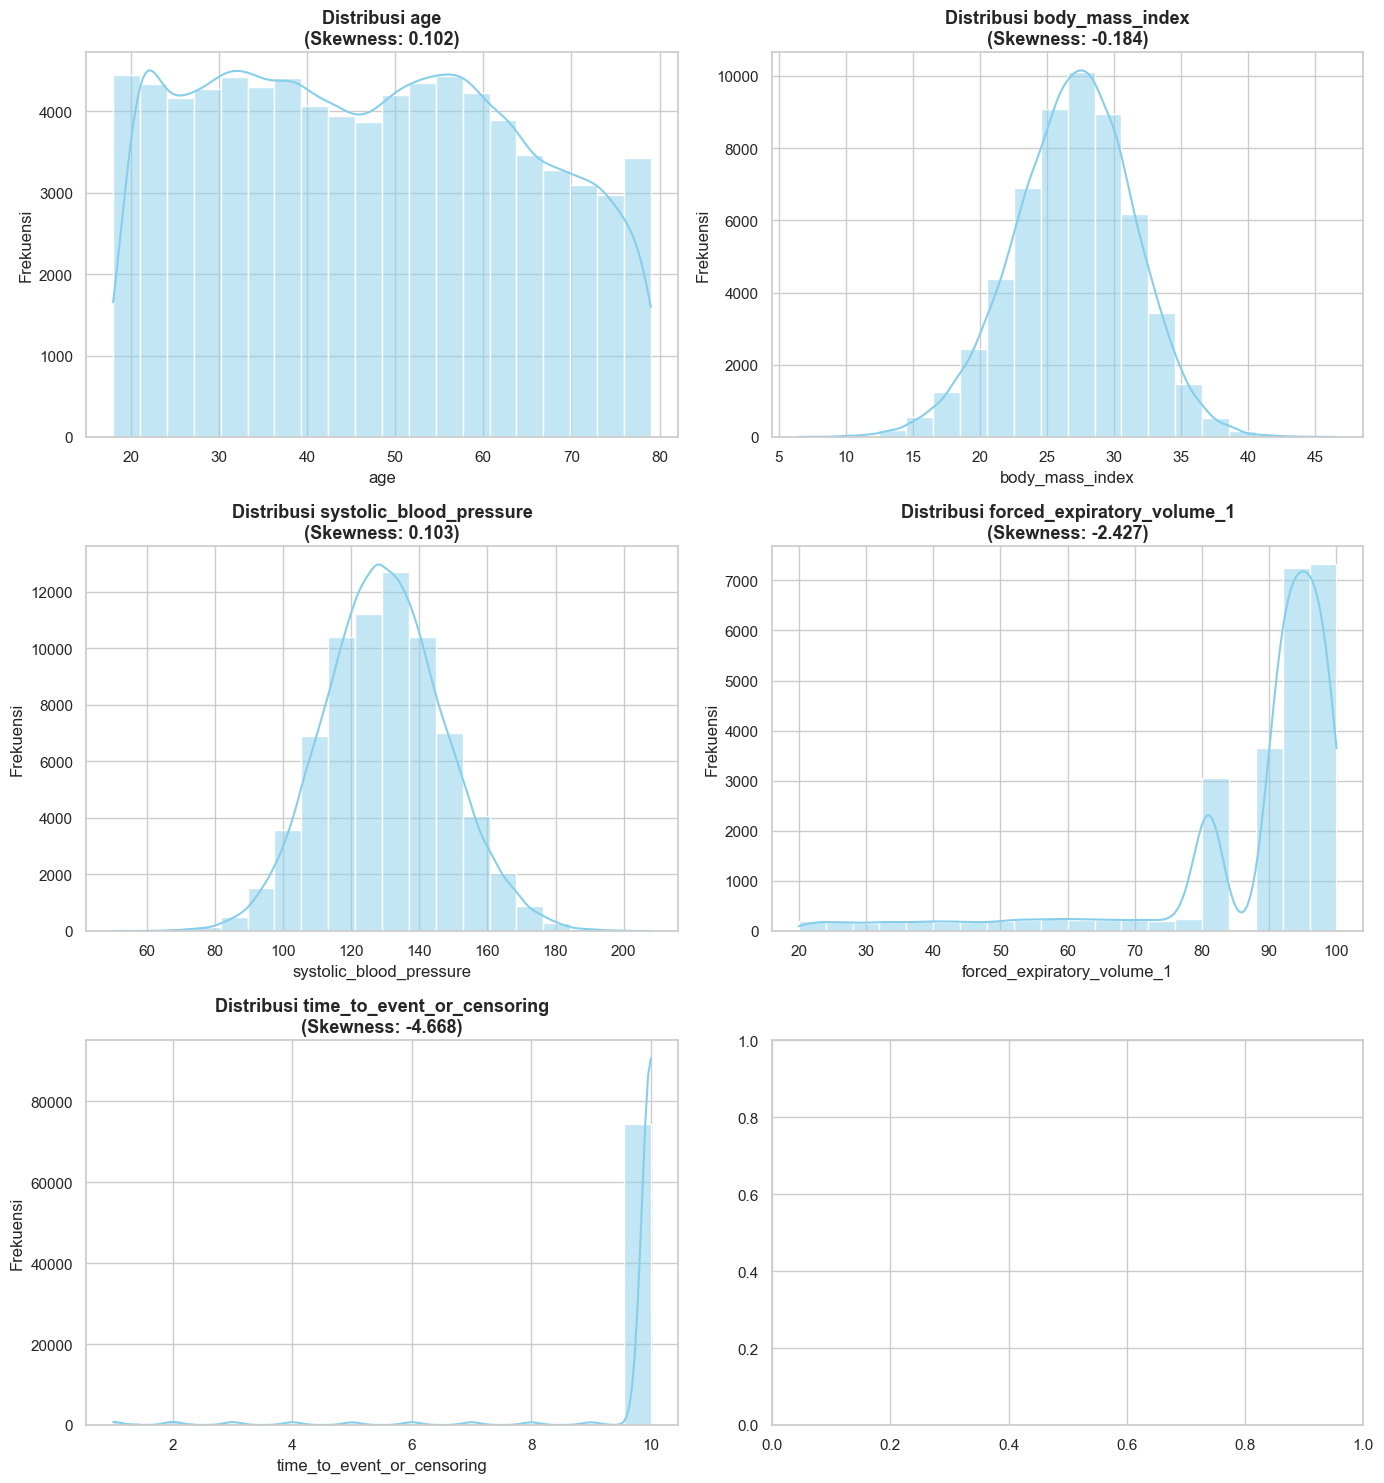

In [27]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(14, 15))
axes = axes.flatten()  # Mengubah matriks axes menjadi array 1 dimensi agar mudah di-loop
# elakukan looping untuk menggambar histogram pada setiap fitur numerik
for i, feature in enumerate(feature_numerik):
    feat_skew = df[feature].skew()
    sns.histplot(df[feature], ax=axes[i], kde=True, color="skyblue", bins=20)
    axes[i].set_title( f"Distribusi {feature}\n(Skewness: {feat_skew:.3f})",fontsize=13,fontweight="bold")
    axes[i].set_xlabel(feature, fontsize=12)
    axes[i].set_ylabel("Frekuensi", fontsize=12)
# engatur tata letak agar tidak tumpang tindih dan menyimpan gambar
plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

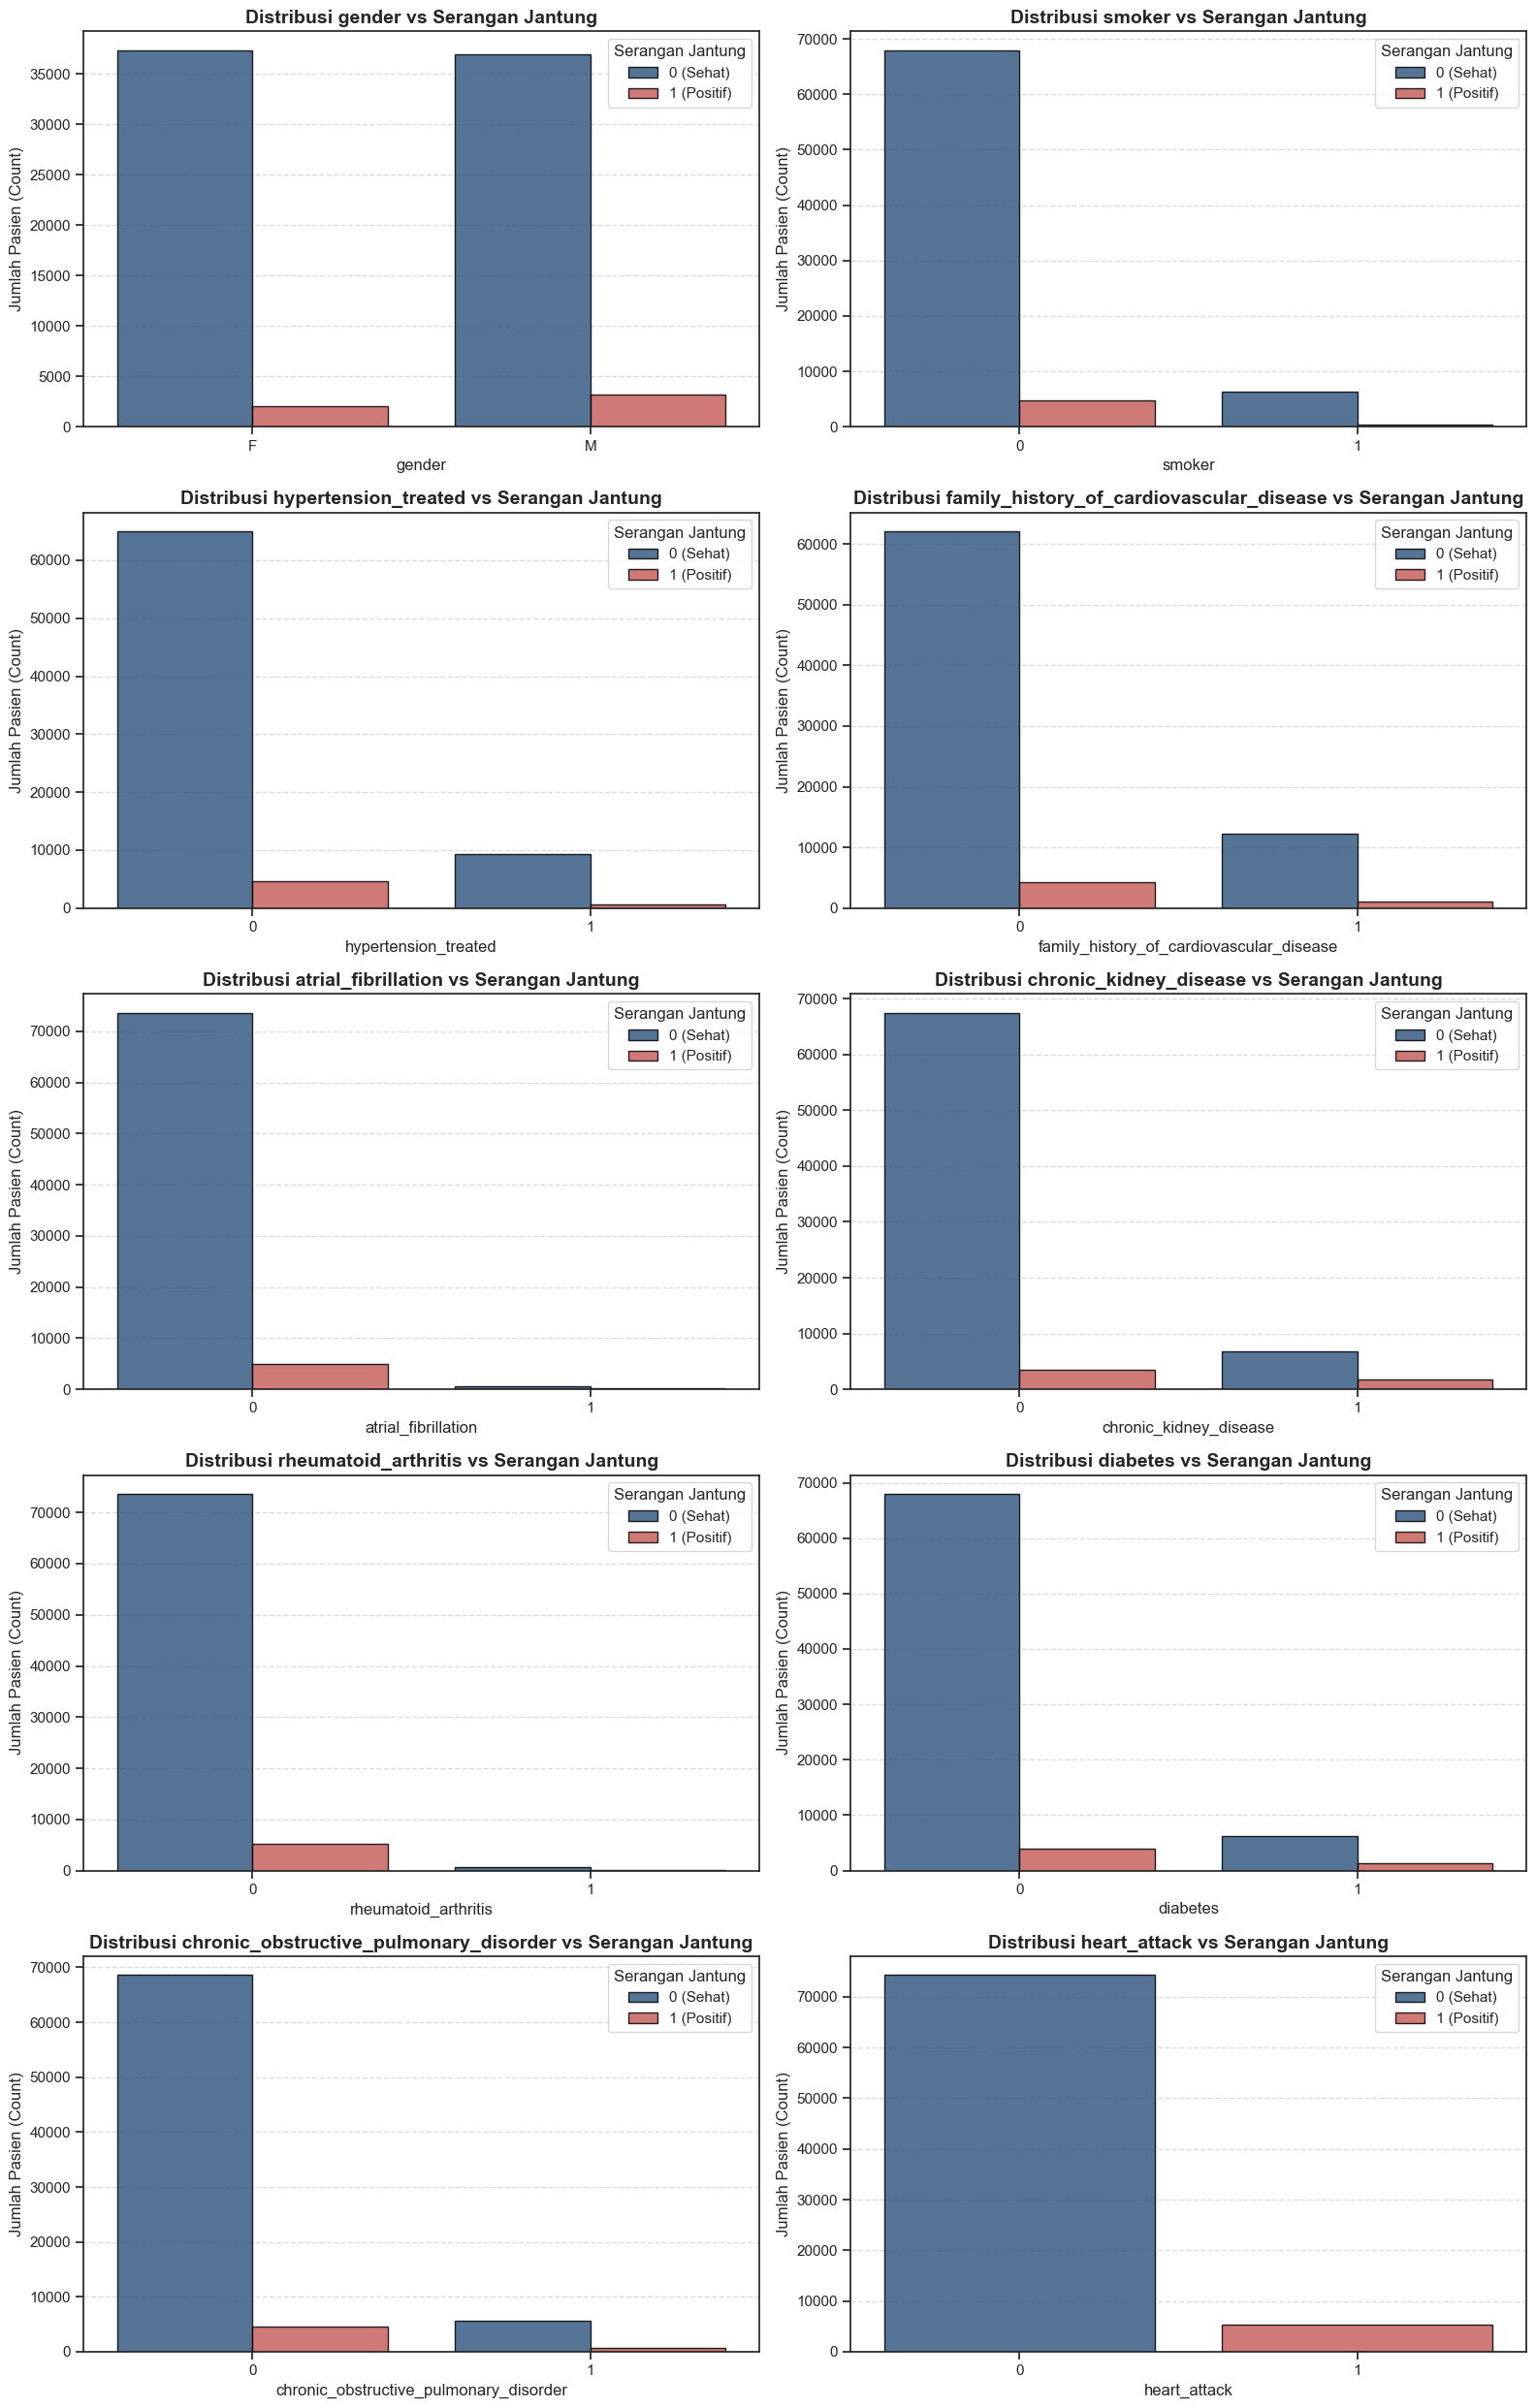

In [28]:
# Mengatur tema visualisasi dan membuat subplots grid 4x2
sns.set_theme(style="ticks")
fig, axes = plt.subplots(5, 2, figsize=(16, 25))
axes = axes.flatten()
# Palet warna kustom untuk membedakan target (0 = Sehat/Biru, 1 = Serangan Jantung/Merah)
colors = {0: "#2b5c8f", 1: "#d9534f"}
for i, feature in enumerate(feature_categori):
    sns.countplot(data=df,x=feature,hue=feature_target,ax= axes[i],palette=colors,edgecolor="black",alpha=0.85,)
    axes[i].set_title(f"Distribusi {feature} vs Serangan Jantung",fontsize=14,fontweight="bold",)
    axes[i].set_xlabel(feature, fontsize=12)
    axes[i].set_ylabel("Jumlah Pasien (Count)", fontsize=12)
    axes[i].legend(title="Serangan Jantung", labels=["0 (Sehat)", "1 (Positif)"])
    axes[i].grid(axis="y", linestyle="--", alpha=0.7)
#Mengatur tata letak agar rapi dan menyimpan gambar ke berkas lokal
plt.tight_layout()
plt.show

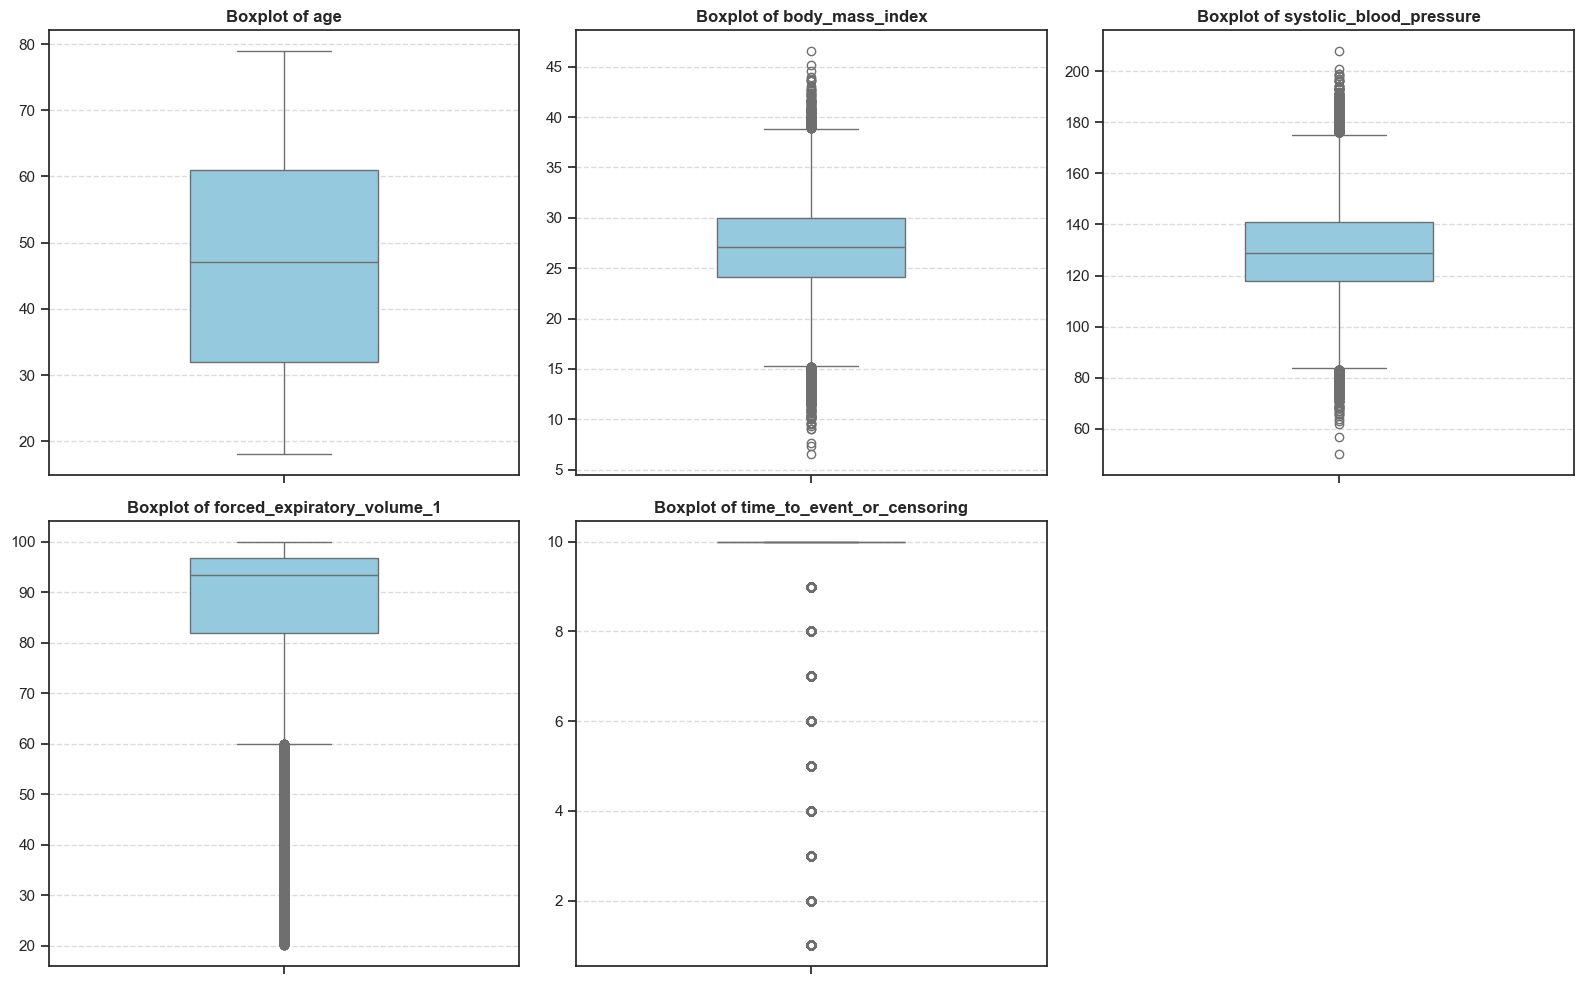

Jumlah outliers terdeteksi: 7911


In [30]:
Q1 = df[feature_numerik].quantile(0.25)
Q3 = df[feature_numerik].quantile(0.75)
IQR = Q3-Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

#.any(axis=1) => "Ambil baris tersebut jika ada MINIMAL SATU kolom saja yang mendeteksi outlier."
outliers = df.loc[((df[feature_numerik] < lower_bound) | (df[feature_numerik] > upper_bound)).any(axis=1)]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(feature_numerik):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue', width=0.4)
    axes[i].set_title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('') # Mengosongkan label y agar lebih bersih
    axes[i].grid(axis='y', linestyle='--', alpha=0.7) # Menambahkan garis bantu
axes[-1].axis('off')
plt.tight_layout()
plt.show()

print(f'Jumlah outliers terdeteksi: {outliers.shape[0]}')

## 2.Handling Missing Value And Outliers

In [31]:
df['body_mass_index'] = df['body_mass_index'].fillna(df['body_mass_index'].mean().round())
df['systolic_blood_pressure'] = df['systolic_blood_pressure'].fillna(df['systolic_blood_pressure'].mean().round())
df['forced_expiratory_volume_1'] = df['forced_expiratory_volume_1'].fillna(df['forced_expiratory_volume_1'].mean().round())

df.isnull().sum()

gender                                      0
age                                         0
body_mass_index                             0
smoker                                      0
systolic_blood_pressure                     0
hypertension_treated                        0
family_history_of_cardiovascular_disease    0
atrial_fibrillation                         0
chronic_kidney_disease                      0
rheumatoid_arthritis                        0
diabetes                                    0
chronic_obstructive_pulmonary_disorder      0
forced_expiratory_volume_1                  0
time_to_event_or_censoring                  0
heart_attack                                0
dtype: int64

In [32]:
df_cleaned= df.loc[((df[feature_numerik] >= lower_bound) & (df[feature_numerik] <= upper_bound)).all(axis=1)]

#cek outliers
outliers = df_cleaned.loc[((df_cleaned[feature_numerik] < lower_bound) | (df_cleaned[feature_numerik] > upper_bound)).any(axis=1)]
print(f'Jumlah outliers terdeteksi: {outliers.shape[0]}')

Jumlah outliers terdeteksi: 0


In [33]:
file_path = "../0.dataset/dataset_Heart_attack_clean.csv"

if not path.exists(file_path):
    # Jika BELUM ADA, simpan data ke CSV
    df_cleaned.to_csv(file_path, index=False)
    print("File belum ada. Berhasil menyimpan dataset baru!")
else:
    # Jika SUDAH ADA, lewati proses penyimpanan
    print("File sudah ada. Proses penyimpanan CSV dilewati (skip).")

df_cleaned.head()

File sudah ada. Proses penyimpanan CSV dilewati (skip).


,gender,age,body_mass_index,smoker,systolic_blood_pressure,hypertension_treated,family_history_of_cardiovascular_disease,atrial_fibrillation,chronic_kidney_disease,rheumatoid_arthritis,diabetes,chronic_obstructive_pulmonary_disorder,forced_expiratory_volume_1,time_to_event_or_censoring,heart_attack
0,F,31,25.9,0,112.0,1,0,0,0,0,0,0,90.969833,10,0
1,F,72,28.6,0,125.0,1,0,0,1,0,0,0,88.000000,10,0
2,F,28,27.0,0,102.0,0,0,0,0,0,0,0,98.376954,10,0
3,F,63,27.0,0,130.0,0,0,0,0,0,0,0,88.000000,10,0
4,F,35,27.0,0,111.0,1,0,0,0,0,0,0,88.000000,10,0
